### Bayesian Inference: Conjugate Priors

#### Understanding Conjugate Priors

A prior distribution is *conjugate* to a likelihood function if the resulting posterior distribution belongs to the same probability distribution family as the prior. This simplifies Bayesian inference as the posterior has a known functional form.

### Beta-Bernoulli Conjugacy

This section illustrates Beta-Bernoulli conjugacy.

*   **Parameter of Interest**: $p$, the probability of success in a Bernoulli trial.
*   **Prior Distribution**: $p \sim \text{Beta}(a, b)$, with PDF $\pi(p) \propto p^{a-1}(1-p)^{b-1}$.
*   **Likelihood Function**: For $n$ Bernoulli trials with $S_n$ successes, $L(X_1, \dots, X_n | p) = p^{S_n}(1-p)^{n-S_n}$.

##### **Deriving the Posterior**

Using Bayes' Theorem, the posterior is $\pi(p | X_1, \dots, X_n) \propto p^{(S_n + a - 1)}(1-p)^{(n - S_n + b - 1)}$, which is a Beta distribution: $\text{Beta}(a + S_n, b + n - S_n)$. Thus, Beta is conjugate to Bernoulli.

True p: 0.7
Observations: [1 0 0 1 1 1 1 0 1 0]
Number of trials (n): 10
Number of successes (S_n): 6

Prior Beta parameters: a=2, b=2
Posterior Beta parameters: a'=8, b'=6


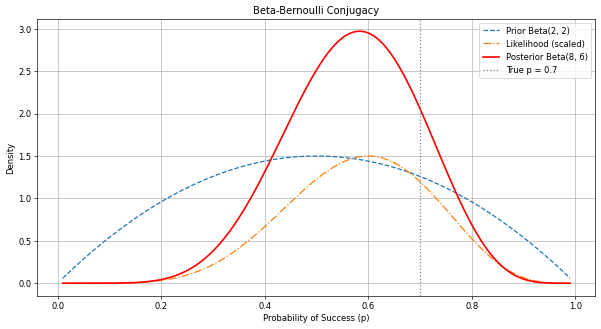

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Prior Parameters
a_prior = 2 ; b_prior = 2

# Simulate Data (Bernoulli Observations)
true_p = 0.7 # The true probability of success
n_observations = 10 # Number of Bernoulli trials

# Generate random Bernoulli observations
np.random.seed(42) # for reproducibility
observations = np.random.binomial(n=1, p=true_p, size=n_observations)

# Calculate number of successes
num_successes = np.sum(observations)
num_failures = n_observations - num_successes

# Calculate Posterior Parameters
a_posterior = a_prior + num_successes
b_posterior = b_prior + num_failures

# Visualize Prior, Likelihood, and Posterior
p_values = np.linspace(0.01, 0.99, 200)

# Prior PDF
prior_pdf = beta.pdf(p_values, a_prior, b_prior)

# Likelihood (proportional to p^S_n * (1-p)^(n-S_n))
# For plotting purposes, we can normalize it to fit on the same scale, though mathematically it's not a PDF
likelihood = p_values**num_successes * (1 - p_values)**num_failures
likelihood = likelihood / np.max(likelihood) * np.max(prior_pdf) #scale for plot

# Posterior PDF
posterior_pdf = beta.pdf(p_values, a_posterior, b_posterior)

This cell visualizes the prior, likelihood, and posterior distributions for the Beta-Bernoulli conjugate pair, showing how observed data updates beliefs.

#### Beta-Bernoulli Conjugacy and Bayesian Estimator

Given a Beta prior $p \sim \text{Beta}(a, b)$ and Bernoulli likelihood $X_i \sim \text{Ber}(p)$,

**Bayesian approach to finding the posterior**

The posterior distribution is derived from Bayes' Theorem: $\pi(p | X_1, \dots, X_n) \propto p^{(\sum X_i + a - 1)}(1-p)^{(n - \sum X_i + b - 1)}$. This is a Beta distribution: $\text{Beta}(\sum X_i + a, n - \sum X_i + b)$.

**Bayesian Estimator $p_{Bayes}$**

The Bayesian estimator, as the posterior mean for a Beta distribution $\text{Beta}(\alpha, \beta)$, is $\frac{\alpha}{\alpha + \beta}$. For the Beta-Bernoulli case, $\hat{p}_{Bayes} = \frac{\sum X_i + a}{n + a + b} = \frac{n\bar{X}_n + a}{n + a + b}$.

**Properties of the Bayesian Estimator**

*   **Consistency**: As $n \to \infty$, $\hat{p}_{Bayes} \to \bar{X}_n \xrightarrow{p} p$. Thus, $\hat{p}_{Bayes}$ is a **consistent estimator**.
*   **Asymptotic Normality**: $\hat{p}_{Bayes}$ is **asymptotically normal** with the same asymptotic variance as the MLE ($V(p) = p(1-p)$), as $\hat{p}_{Bayes}$ converges to $\bar{X}_n$ by CLT.

**Simulate Bayesian Convergence** (Beta-Bernoulli)

Simulate Bayesian inference for Beta-Bernoulli conjugacy to observe how the posterior distribution of $p$ converges to its true value with more data.

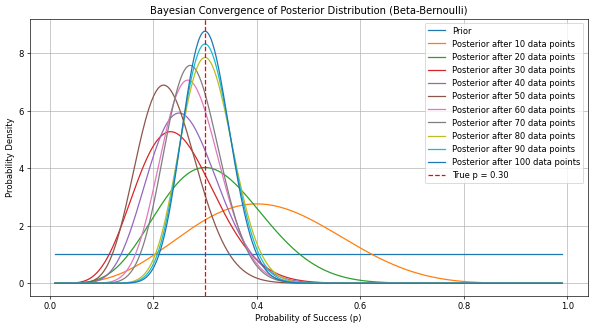

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Simulation Parameters
true_p = 0.3  # The true probability of success
n_observations = 100 # Total number of observations to simulate

# Prior Parameters (Beta distribution)
a_prior = 1  # Alpha parameter
b_prior = 1  # Beta parameter

# Create an array of p values for plotting distributions
p_values = np.linspace(0.01, 0.99, 500)

# Generate Data
np.random.seed(42)  # For reproducibility
observations = np.random.binomial(n=1, p=true_p, size=n_observations)

# Store posterior parameters and distributions at different stages
posterior_states = []

# Initial prior (before any observations)
current_a = a_prior
current_b = b_prior
posterior_states.append({
    'num_data': 0, 'a_post': current_a, 'b_post': current_b,
    'pdf': beta.pdf(p_values, current_a, current_b)
})

# Update posterior with accumulating observations
for i, obs in enumerate(observations):
    if obs == 1:
        current_a += 1
    else:
        current_b += 1

    # Store state at specific intervals or at the end
    if (i + 1) % 10 == 0 or (i + 1) == n_observations:
        posterior_states.append({
            'num_data': i + 1, 'a_post': current_a, 'b_post': current_b,
            'pdf': beta.pdf(p_values, current_a, current_b)
        })

#### Analysis of Convergence

The **Prior** (blue line) represents initial beliefs. As **observations** are incorporated, the posterior distribution (red line) shifts and narrows, demonstrating data-driven belief updates. With sufficient data, the posterior concentrates around the **True $p$ value** (red dashed line), indicating increased precision. This confirms Bayesian estimator consistency: posterior converges to a point mass at the true parameter as sample size ($n$) increases.